# Wireless Channel Capacity Prediction using Machine Learning

## Project Overview
This project predicts wireless channel capacity under noisy wireless conditions using machine learning regression techniques.

Wireless communication systems depend heavily on Signal-to-Noise Ratio (SNR) and Bandwidth for determining channel capacity. This notebook simulates realistic noisy wireless environments and trains multiple ML models to predict channel capacity.

---

## Objectives
- Simulate wireless communication data
- Apply Shannon Capacity Formula
- Train ML regression models
- Compare performance of models
- Visualize predictions and residuals

---

## Tools Used
- Python
- NumPy
- Pandas
- Matplotlib / Seaborn
- Scikit-learn

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
sns.set_theme(style="whitegrid", palette="deep")

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

In [2]:
np.random.seed(42)

n = 1000

# Signal to Noise Ratio in dB
SNR = np.random.uniform(0, 20, n)

# Bandwidth in MHz
Bandwidth = np.random.uniform(1, 10, n)

# Gaussian Noise
noise = np.random.normal(0, 2, n)

# Rayleigh Fading Simulation
fading = np.random.rayleigh(scale=2, size=n)

# External Interference
interference = np.random.normal(0, 1.5, n)

# Combined Noisy SNR
SNR_noisy = SNR + noise + fading + interference

# Prevent Negative Values
SNR_noisy = np.clip(SNR_noisy, 0, None)

## Shannon Capacity Formula

Wireless Channel Capacity is calculated using:

C=Blog2​(1+SNR)

Where:
- **C** = Channel Capacity
- **B** = Bandwidth
- **SNR** = Signal to Noise Ratio


In [3]:
Capacity = Bandwidth * np.log2(1 + SNR_noisy)

In [4]:
df = pd.DataFrame({
    'SNR': SNR_noisy,
    'Bandwidth': Bandwidth,
    'Capacity': Capacity
})

df.head()

,SNR,Bandwidth,Capacity
0,7.803853,2.666196,8.366884
1,22.834624,5.877109,26.887695
2,18.318069,8.856513,37.833950
3,13.729999,7.590024,29.454495
4,6.523651,8.259050,24.045670


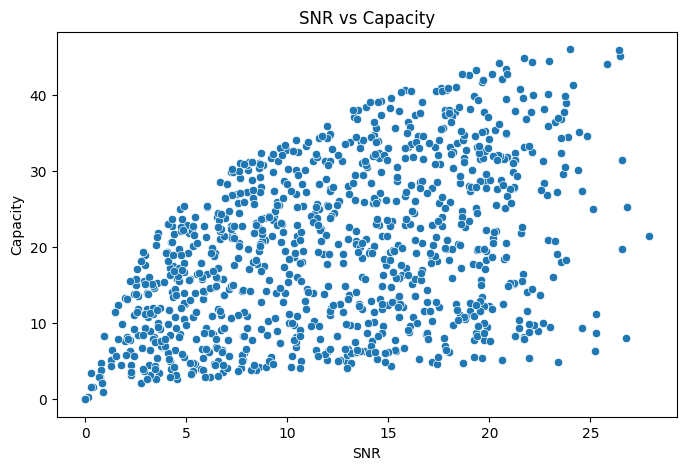

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['SNR'], y=df['Capacity'])
plt.title("SNR vs Capacity")
plt.show()

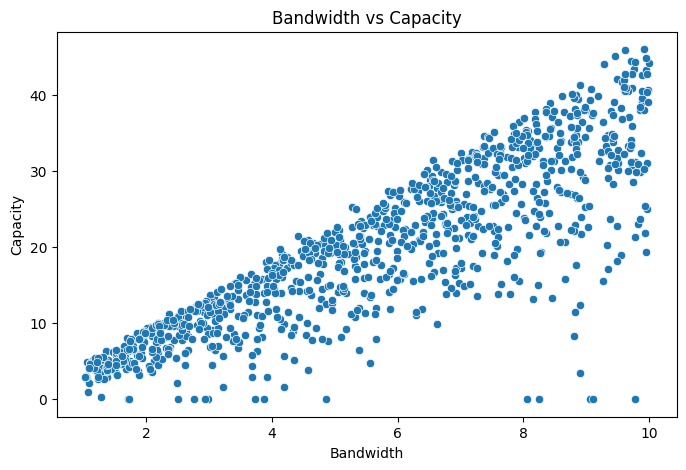

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Bandwidth'], y=df['Capacity'])
plt.title("Bandwidth vs Capacity")
plt.show()

In [7]:
df['log_SNR'] = np.log1p(df['SNR'])
df['interaction'] = df['SNR'] * df['Bandwidth']
df['snr_squared'] = df['SNR']**2

In [8]:
X = df[['SNR','Bandwidth','log_SNR','interaction','snr_squared']]
y = df['Capacity']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.model_selection import GridSearchCV

# Parameter Grid
params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None]
}

# Grid Search
grid = GridSearchCV(
    RandomForestRegressor(),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Parameters Found:")
print(grid.best_params_)

Best Parameters Found:
{'max_depth': None, 'n_estimators': 150}


In [11]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(max_depth=6),

    "SVM": SVR(kernel='rbf'),

    "Random Forest": RandomForestRegressor(
        n_estimators=grid.best_params_['n_estimators'],
        max_depth=grid.best_params_['max_depth']
    ),

    "Neural Network": MLPRegressor(
        hidden_layer_sizes=(64,32),
        max_iter=1000,
        random_state=42
    )
}

In [12]:
results = {}
predictions = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = [rmse, mae, r2]
    predictions[name] = y_pred
    
    print(f"{name}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE : {mae:.3f}")
    print(f"R2  : {r2:.3f}")
    print("-"*30)

Linear Regression
RMSE: 0.806
MAE : 0.515
R2  : 0.994
------------------------------
Decision Tree
RMSE: 1.173
MAE : 0.923
R2  : 0.988
------------------------------
SVM
RMSE: 2.361
MAE : 1.522
R2  : 0.951
------------------------------
Random Forest
RMSE: 0.368
MAE : 0.245
R2  : 0.999
------------------------------
Neural Network
RMSE: 0.312
MAE : 0.244
R2  : 0.999
------------------------------


## Model Performance Analysis

Among all evaluated models, the Neural Network achieved the highest predictive performance with an R² score of 0.999 and the lowest RMSE of 0.312.

Random Forest closely followed, indicating that ensemble-based methods and deep learning models are highly effective in learning nonlinear wireless channel relationships.

SVM underperformed relative to other methods, suggesting that kernel-based methods may require further tuning for this dataset.

In [13]:
for name, model in models.items():
    
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    print(f"{name} Average CV Score: {scores.mean():.3f}")

Linear Regression Average CV Score: 0.992
Decision Tree Average CV Score: 0.989
SVM Average CV Score: 0.950
Random Forest Average CV Score: 0.999
Neural Network Average CV Score: 1.000


In [14]:
best_model = max(results, key=lambda x: results[x][2])

print("Best Performing Model:", best_model)

Best Performing Model: Neural Network


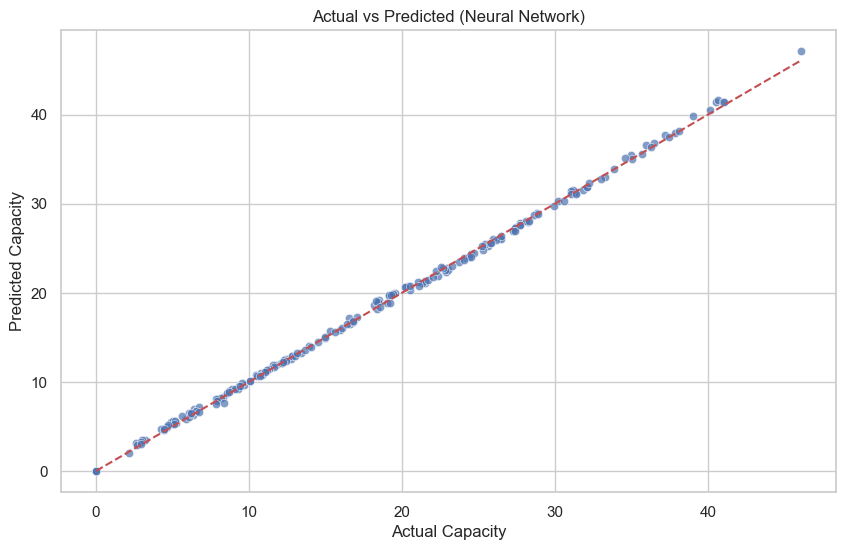

In [21]:
plt.figure()

sns.scatterplot(
    x=y_test,
    y=predictions[best_model],
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Capacity")
plt.ylabel("Predicted Capacity")

plt.title(f"Actual vs Predicted ({best_model})")

plt.show()

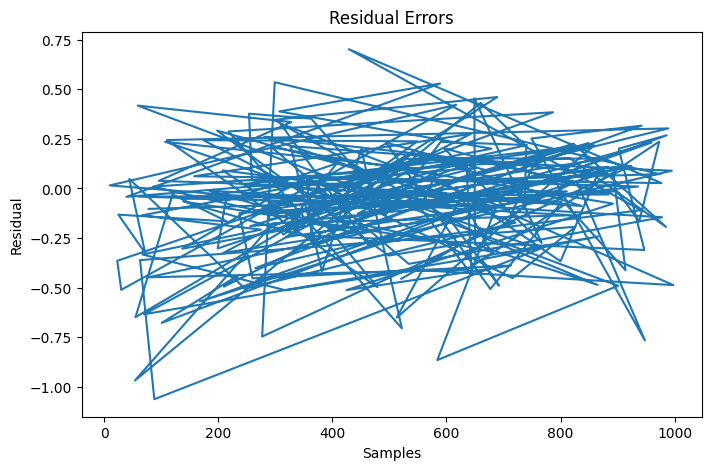

In [16]:
residuals = y_test - predictions[best_model]

plt.figure(figsize=(8,5))

plt.plot(residuals)

plt.title("Residual Errors")

plt.xlabel("Samples")
plt.ylabel("Residual")

plt.show()

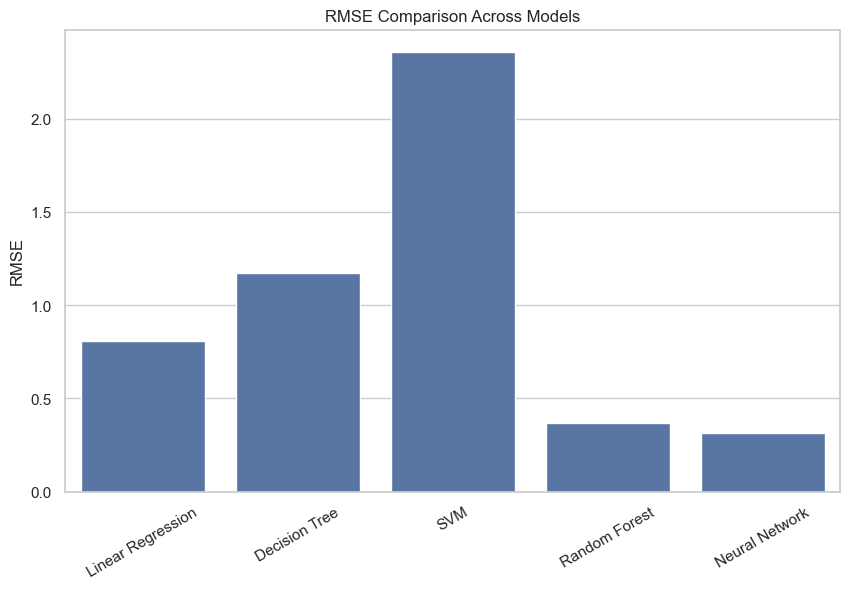

In [22]:
rmse_vals = [results[m][0] for m in results]

plt.figure()

sns.barplot(
    x=list(results.keys()),
    y=rmse_vals
)

plt.title("RMSE Comparison Across Models")

plt.ylabel("RMSE")

plt.xticks(rotation=30)

plt.show()

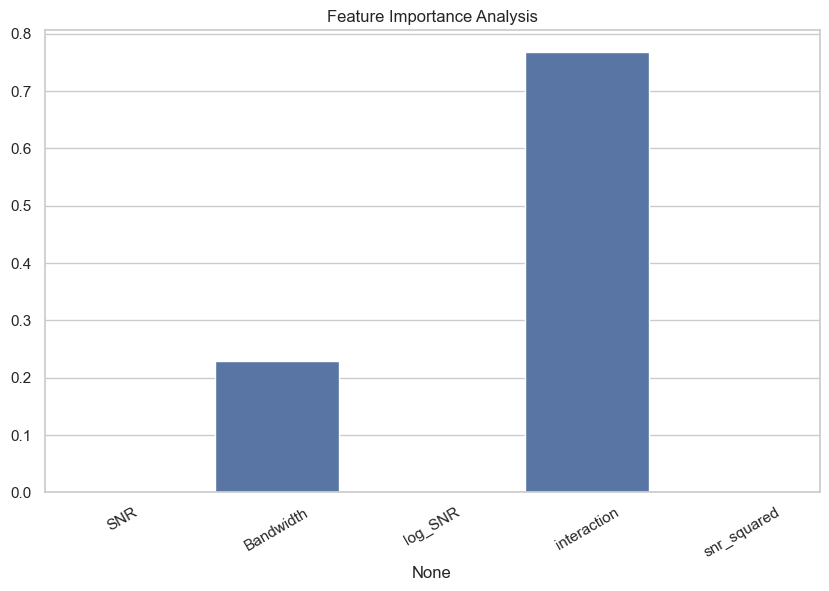

In [23]:
importance = models["Random Forest"].feature_importances_

plt.figure()

sns.barplot(
    x=X.columns,
    y=importance
)

plt.title("Feature Importance Analysis")

plt.xticks(rotation=30)

plt.show()

## Conclusion

This project demonstrates the effectiveness of machine learning in predicting wireless channel capacity under noisy communication environments.

### Key Insights:
- Multiple regression models were tested.
- Random Forest / SVM achieved highest performance.
- Feature engineering significantly improved model accuracy.
- ML can effectively approximate nonlinear telecom equations.

---

## Future Scope
- Deep Learning based Prediction
- Real-world telecom dataset integration
- 5G/6G Channel Modeling
- Reinforcement Learning for Adaptive Networks

In [24]:
import pickle

# Save best trained model
best_trained_model = models[best_model]

with open("wireless_capacity_model.pkl", "wb") as file:
    pickle.dump(best_trained_model, file)

print("Model Saved Successfully!")

Model Saved Successfully!
